# Cardiovascular Disease Prediction

# Data Collection

## Why It's Important
 Cardiovascular disease is the leading cause of death worldwide, making early detection and prevention critical for public health. Closely observing the factors that contribute to cardiovascular disease can help identify high-risk individuals and inform healthcare strategies.


## Project Objective
This project aims to predict the likelihood of cardiovascular disease based on various health and lifestyle metrics.

## Hypothesis
 Can we predict the presence of cardiovascular disease using routine health and lifestyle data such as age, blood pressure, cholesterol, BMI, smoking, and alcohol intake?

Formal Hypotheses:
- Null Hypothesis (H0): Health and lifestyle features do not significantly predict cardiovascular disease.
- Alternative Hypothesis (H1): Health and lifestyle features significantly predict cardiovascular disease.

Additional Consideration: Which patient features are most strongly associated with cardiovascular disease risk?

## Population
The population consists of adults from Moscow, Russia who underwent medical examinations. The dataset includes a diverse mix of ages, sexes, and lifestyles representing a wide range of demographic, behavioral, and clinical characteristics.

## Variables
The independent variables will include:
- Age (denoted in days)
- Gender (1 = women, 2 = men)
- Height (cm), Weight (kg)
- Blood Pressure (systolic, diastolic)
- Cholesterol, Glucose
- Smoking, Alcohol intake, Physical activity

The dependent variable will be:
- cardio: 1 = diagnosed with cardiovascular disease, 0 = no disease

Cofounding (third) variables could potentially be:
- environmental factors, genetic predisposition, diet, or any other factors that are not captured in the dataset.

  - The confounding variables like environemtal factors are not in the current dataset. In the case for environmental factors, I plan on augemnting and or incorporating it with the current dataset by merging an external dataset like air quality index (AQI) for Moscow, Russia. This will allow me to include a measure of environmental factors (e.g. PM2.5 levels) as a control variable in future modeling steps.

## Plan for data collection

The dataset will be downloaded from Kaggle using the KaggleHub library. It includes roughly 70,000 adult patients. In the future, additional relevant datasets (e.g., environmental data, socioeconomic indicators) could be merged if I need to enhance analysis.


Source:
- Kaggle Cardiovascular Disease dataset
: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset


## Choosing Dataset
Explain why this dataset is interesting to you

This dataset is highly valuable for predictive modeling because it combines clinical measurements (blood pressure, cholesterol, glucose) with lifestyle factors (smoking, alcohol consumption, and physical activity). With 70,000 patient records, it provides a large and diverse sample for statistical analysis and machine learning experiments. Addtionally, the data is clean, tabular and well-structured making it ideal for exploratory data analysis, feature engineering, and classification modeling.


1. What is in the dataset?
- This dataset has 70,000 rows with 12 features.
2. Where is the dataset from?
  - The dataset is from Kaggle
3. When is the dataset from?
- The dataset is from a modern clinical examination from Moscow, Russia

In [1]:
# install kagglehub if not installed
!pip install kagglehub --quiet

import kagglehub as kh
import pandas as pd

# get Cardiovascular Disease dataset path from Kaggle
raw_data_path = kh.dataset_download('sulianova/cardiovascular-disease-dataset')

df = pd.read_csv(raw_data_path + "/cardio_train.csv", sep=";")

print("\nFirst 5 Rows of Dataset:")
print(df.head(5))


100%|██████████| 742k/742k [00:00<00:00, 88.2MB/s]

Extracting files...

First 5 Rows of Dataset:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


# Data Pre-Processing

## 1. Preliminary information about the Dataset

In [2]:
# Shape of the data
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

# List of columns
print("\nDataset columns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Quick descriptive statistics
df.describe(include='all')


Dataset shape: 70000 rows and 13 columns

Dataset columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


As we can see:
- Shape: 70,000 rows x 13 columns
- Variables: id, age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active, cardio
- Data types are mostly all numeric (either int64 or float64)
- Notice that some blood-pressure values are clearly unrelalistic (e.g. systolic > 16,000 mmHg). We will handle these later in the data cleaning process

## 2. Specific Data Needs

At this stage, we focus mostly on the Kaggle Cardiovascular Disease dataset which contains a comprehensive mix of clinical and lifestyle factors for over 70,000 individuals. This dataset is sufficient for initial preprocessing, exploratory analysis, and model prototyping. In future iterations, I plan to incorporate external datasets that capture environmental and contextual factors, which can serve as potential confounders influencing cardiovascular health outcomes. For now the focus will be on the larger datset that I have currently.

Potential supplementary datasets:

- Moscow Weather Data - NOAA GHCN-Daily
  - This dataset will provide daily weather measurements such as temperature, humidity, and precipitation. Including weather variables will help control for climatic variability, as extreme temperatures and seasonal changes can influence both cardiovascular risk and patient behavior (for example, reduced physical activity or delayed medical visits)
- Air Quality Data (AQI/Pollutants) - World Air Quality Index
  - Air pollution metrics (e.g., PM2.5, PM10, CO, NO₂ levels) are established environmental risk factors for cardiovascular disease. Integrating city-level AQI data for Moscow will allow the inclusion of an environmental exposure variable, offering a more comprehensive view of external health determinants.

## 3. Potential issues in the data




### Duplicate Rows

In [3]:
#check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If duplicates exist, show them
if duplicates > 0:
    display(df[df.duplicated()])

Number of duplicate rows: 0


Observe that we get 0 duplicates which is a good sign of data integrity

### Missing or Null values

In [4]:
# check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)


Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


We see that there are no missing values in any column, thus will not require much imputation

### Unique Values per Column

In [5]:
# checking for unique values
unique_counts = df.nunique()
print("\nUnique values per column:")
print(unique_counts)



Unique values per column:
id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64


Key Observations:
- The "id" column has 70,000 unique vaules where each record represents one patient
- Variables like cholesterol, glucose, smoke, alco, active, and cardio have few unique values. This can be beneficial for categorical encoding later on.

### Outliers

In [6]:
# checking for outliers using z-score
from scipy import stats
import numpy as np

numeric_data = ['height', 'weight', 'ap_hi', 'ap_lo']
z_scores = np.abs(stats.zscore(df[numeric_data]))
outliers = (z_scores > 3).any(axis=1)


print("\nChecking for potential outliers per column:")
df[outliers].head()


Checking for potential outliers per column:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1,1,0,0,1,0
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1


We see that there are some extreme outlier found in blood-pressure columns (ap_hi and ap_lo) such as systolic > 1000 mmHg. These are unrealistic and will need to be filtered out.

## 4. Reorganization and Renaming


In [7]:
# rename some column for readability
df.rename(columns={
    'ap_hi': 'systolic_bp',
    'ap_lo': 'diastolic_bp',
    'alco': 'alcohol_intake',
    'active': 'physical_activity'
}, inplace=True)

df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake',
       'physical_activity', 'cardio'],
      dtype='object')

These columns were renamed for clarity: e.g. "systolic_bp" instead of "ap_hi" and "physical_activity" instead of "active"

## 5. Data Cleaning Plan

Based on the findings from above, we need to:
- filter the blood pressure values for a realistic range (80-250 / 50-150 mmHg) and reduce data-entry errors
- use realistic height/weight to remove any anamolies - keep 120-220 cm / 30 - 200 kg
- convert age from days to years for easier interpretation
- rename and reorder columns for readability

## 6. Apply Data Cleaning Plan

In [8]:
# remove any duplicates
df.drop_duplicates(inplace=True)

# remove improbable blood-pressure values
df = df[df['systolic_bp'].between(80, 250)]
df = df[df['diastolic_bp'].between(50, 150)]


# remove unrealistic heights and weights
df = df[df['height'].between(120, 220)]
df = df[df['weight'].between(30, 200)]

# convert age from days to years (as integer)
df['age'] = (df['age'] / 365).astype(int)

# reordering columns
cols = ['id', 'age', 'gender', 'height', 'weight', 'systolic_bp',
        'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake',
        'physical_activity', 'cardio']

df = df[cols]



## 7. Verify Results after Cleaning

In [9]:
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nChecking for missing values")
print(df.isnull().sum())

df.describe()

Dataset shape: 68665 rows and 13 columns

Dataset columns:
['id', 'age', 'gender', 'height', 'weight', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity', 'cardio']

Data types:
id                     int64
age                    int64
gender                 int64
height                 int64
weight               float64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
gluc                   int64
smoke                  int64
alcohol_intake         int64
physical_activity      int64
cardio                 int64
dtype: object

Checking for missing values
id                   0
age                  0
gender               0
height               0
weight               0
systolic_bp          0
diastolic_bp         0
cholesterol          0
gluc                 0
smoke                0
alcohol_intake       0
physical_activity    0
cardio               0
dtype: int64


,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol,gluc,smoke,alcohol_intake,physical_activity,cardio
count,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000,68665.000000
mean,49974.686565,52.829476,1.348809,164.416078,74.121461,126.628078,81.363912,1.364800,1.225938,0.088022,0.053521,0.803379,0.494866
std,28846.844212,6.767963,0.476597,7.914118,14.295434,16.719983,9.522436,0.679024,0.571886,0.283328,0.225071,0.397446,0.499977
min,0.000000,29.000000,1.000000,120.000000,30.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25002.000000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50019.000000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74870.000000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.000000,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


After cleaning the data we get:
- The number of rows reduced from 70,000 --> 68,665 after removing outliers
- No missing or duplicate values
- normalized ranges for height, weight, and blood pressure to a realistic standard
- The average age of a patient is about 53 years

## 8. Save Cleaned Data



In [10]:
# save cleaned dataset
df.to_csv('cardio_cleaned.csv', index=False)
print("Saved cleaned dataset to 'cardio_cleaned.csv'")

Saved cleaned dataset to 'cardio_cleaned.csv'


## 9. Import Cleaned dataset

In [11]:
# import the cleaned dataset
df_clean_data = pd.read_csv('cardio_cleaned.csv')
print("Loading new dataset with shape:", df_clean_data.shape)

Loading new dataset with shape: (68665, 13)


## 10. Display First and Last 5 Rows

In [12]:
print("\nFirst 5 Rows of Cleaned Dataset:")
print(df_clean_data.head())

print("\nLast 5 Rows of Cleaned Dataset:")
print(df_clean_data.tail())


First 5 Rows of Cleaned Dataset:
   id  age  gender  height  weight  systolic_bp  diastolic_bp  cholesterol  \
0   0   50       2     168    62.0          110            80            1   
1   1   55       1     156    85.0          140            90            3   
2   2   51       1     165    64.0          130            70            3   
3   3   48       2     169    82.0          150           100            1   
4   4   47       1     156    56.0          100            60            1   

   gluc  smoke  alcohol_intake  physical_activity  cardio  
0     1      0               0                  1       0  
1     1      0               0                  1       1  
2     1      0               0                  0       1  
3     1      0               0                  1       1  
4     1      0               0                  0       0  

Last 5 Rows of Cleaned Dataset:
          id  age  gender  height  weight  systolic_bp  diastolic_bp  \
68660  99993   52       2     16

# Data Exploration & Visualization

## Initial Thoughts

Looking at the data so far, we have retrieved the cardiovascular dataset data from Kaggle, performed some preprocessing and saved that new dataset called `cardio_cleaned.csv`.



This dataset contains:
- clinical measure (blood pressure, cholesterol, glucose)
-  demographics (age, gender)
- lifestyle (smoking, alcohol, physical activity)


Looking at these data points, at glance I would assume that age, systolic blood pressurem and smoking will show a strong correlation to `cardio`. One thing that I do want to explore is whether BMI, that we calcuated using heigh and weight, is a good predictor for someone having cardiovascular disease.

Some questions to keep in mind as we explore and try to build our models:
1. How balanced is the target (`cardio`)? Are there are class imbalances
2. How do numeric distributions look? Do we see any skew or outlier?
3. Are there strong correlations between predictors that might cause multicollinearity?
4. Do subgroup patterns (gender) change relationships?

## Characteristics of the data



In [13]:
# Each row in the dataset represents one patient

# Shape
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())


# counts for target and gender
print("\nCardio Distribution:\n", df['cardio'].value_counts(normalize=False))
print("\nCardio proportion:\n", df['cardio'].value_counts(normalize=True))
print("\nGender Distribution:\n", df['gender'].value_counts())


Shape: (68665, 13)

Columns: ['id', 'age', 'gender', 'height', 'weight', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity', 'cardio']

Cardio Distribution:
 cardio
0    34685
1    33980
Name: count, dtype: int64

Cardio proportion:
 cardio
0    0.505134
1    0.494866
Name: proportion, dtype: float64

Gender Distribution:
 gender
1    44714
2    23951
Name: count, dtype: int64


## Additional Transformations / derived variables

In [15]:
# Create BMI from height (convert from cm to meters)
# and weight and store it as a new column
df['height_meters'] = df['height'] / 100.0
df['bmi'] = df['weight'] / (df['height_meters'] ** 2)

df['gender_label'] = df['gender'].map({1: 'Female', 2: 'Male'})

df[['height', 'weight', 'height_meters', 'bmi', 'gender_label']].head()

,height,weight,height_meters,bmi,gender_label
0,168,62.0,1.68,21.967120,Male
1,156,85.0,1.56,34.927679,Female
2,165,64.0,1.65,23.507805,Female
3,169,82.0,1.69,28.710479,Male
4,156,56.0,1.56,23.011177,Female


BMI is a meaningful derived feature as it is often a major factor associated with those that are at risk or have cardiovascular disease.

## Exploring Variables

### Age

count    68665.000000
mean        52.829476
std          6.767963
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


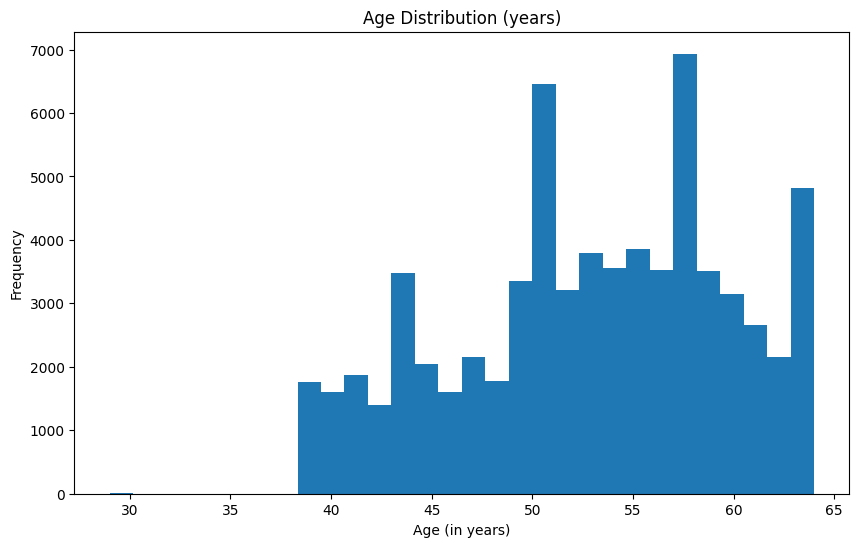

In [21]:
import matplotlib.pyplot as plt

print(df['age'].describe())


plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=30)
plt.xlabel('Age (in years)')
plt.ylabel('Frequency')
plt.title('Age Distribution (years)')
plt.show()

### BMI, Height, Weight

count    68665.000000
mean        27.459055
std          5.256908
min         10.726644
25%         23.875115
50%         26.346494
75%         30.119376
max        108.169847
Name: bmi, dtype: float64


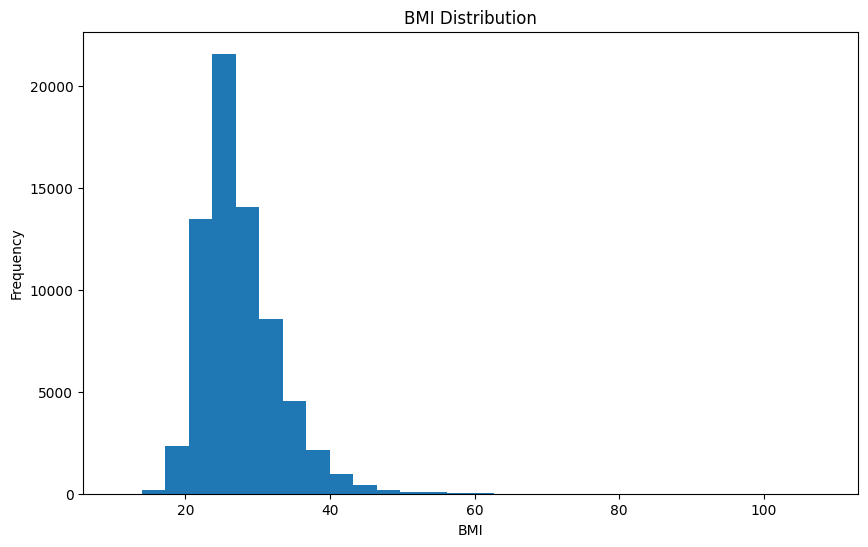

In [33]:
print(df['bmi'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['bmi'], bins=30)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()



count    68665.000000
mean       164.416078
std          7.914118
min        120.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        207.000000
Name: height, dtype: float64


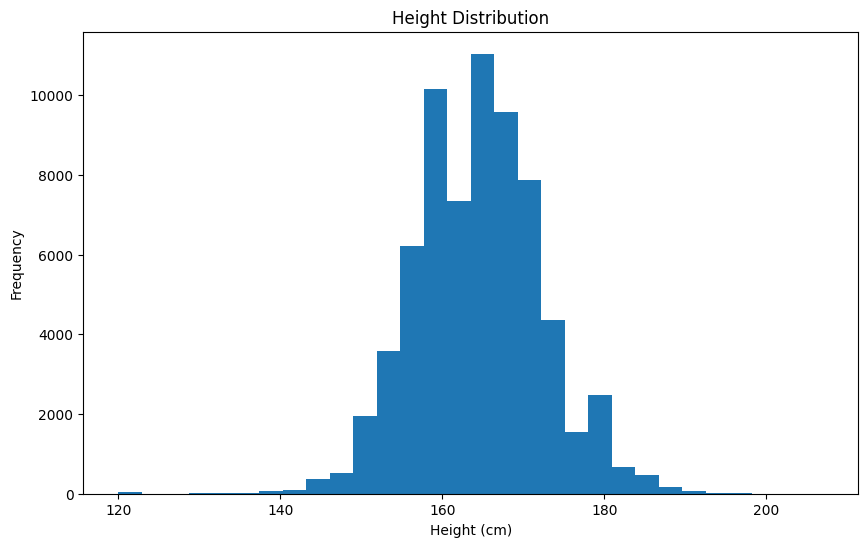

In [32]:
print(df['height'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['height'], bins=30)
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

count    68665.000000
mean        74.121461
std         14.295434
min         30.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64


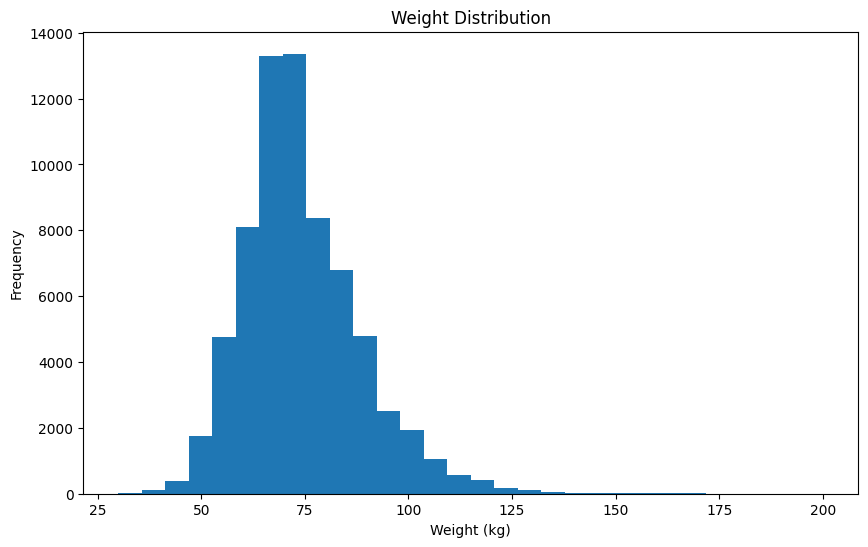

In [31]:
print(df['weight'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['weight'], bins=30)
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.title('Weight Distribution')
plt.show()

### Blood Pressure (systolic/diastolic)

        systolic_bp  diastolic_bp
count  68665.000000  68665.000000
mean     126.628078     81.363912
std       16.719983      9.522436
min       80.000000     50.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    150.000000


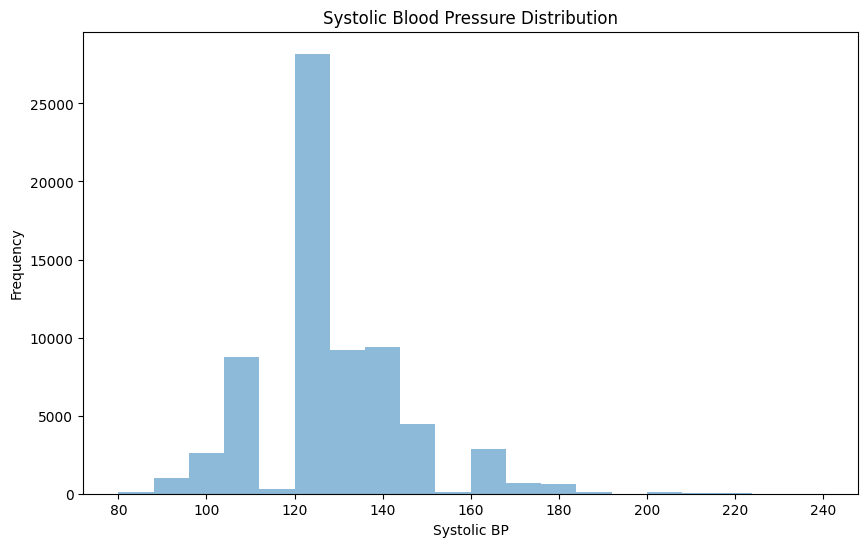

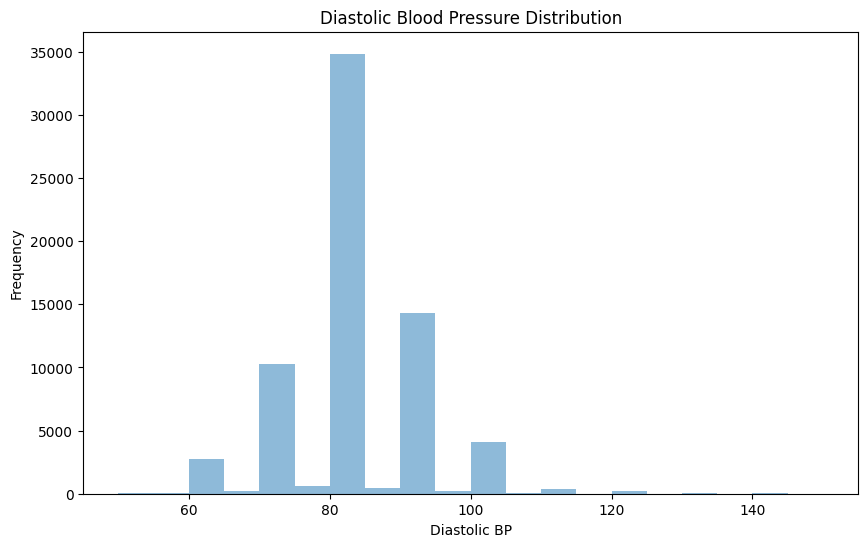

In [38]:
print(df[['systolic_bp', 'diastolic_bp']].describe())

plt.figure(figsize=(10, 6))
plt.hist(df['systolic_bp'], bins=20, alpha=0.5, label='Systolic BP')
plt.title('Systolic Blood Pressure Distribution')
plt.xlabel('Systolic BP')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(df['diastolic_bp'], bins=20, alpha=0.5, label='Diastolic BP')
plt.title('Diastolic Blood Pressure Distribution')
plt.xlabel('Diastolic BP')
plt.ylabel('Frequency')
plt.show()

Observe that systolic peaks around ~120–140, diastolic around ~80–90.

### Categorical variables


Count for: cholesterol
cholesterol
1    51490
2     9301
3     7874
Name: count, dtype: int64


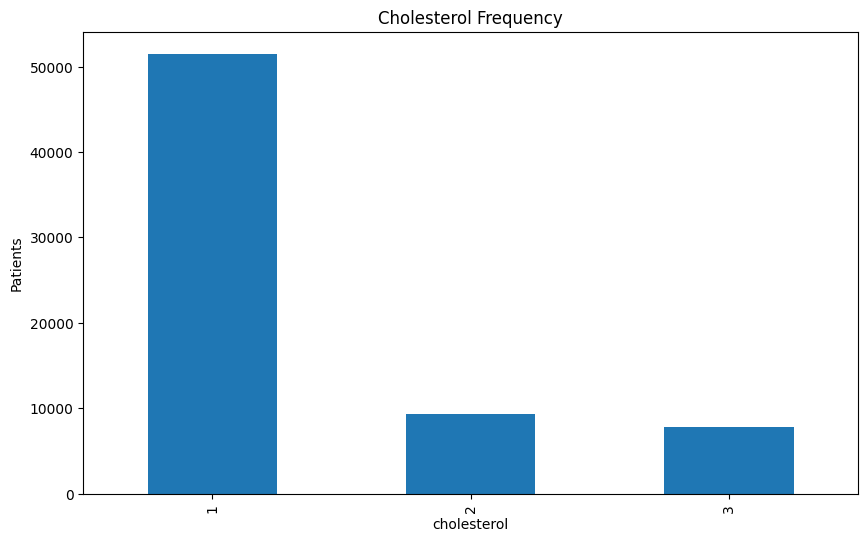


Count for: gluc
gluc
1    58375
3     5224
2     5066
Name: count, dtype: int64


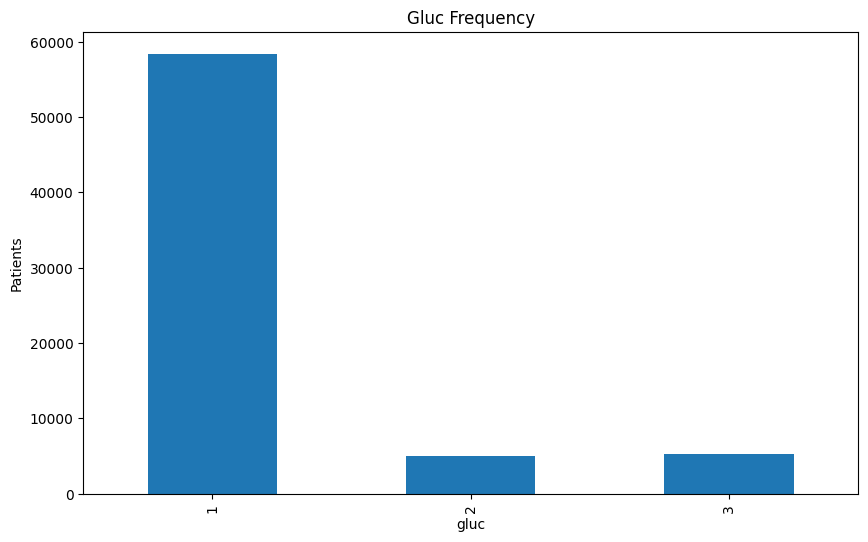


Count for: smoke
smoke
0    62621
1     6044
Name: count, dtype: int64


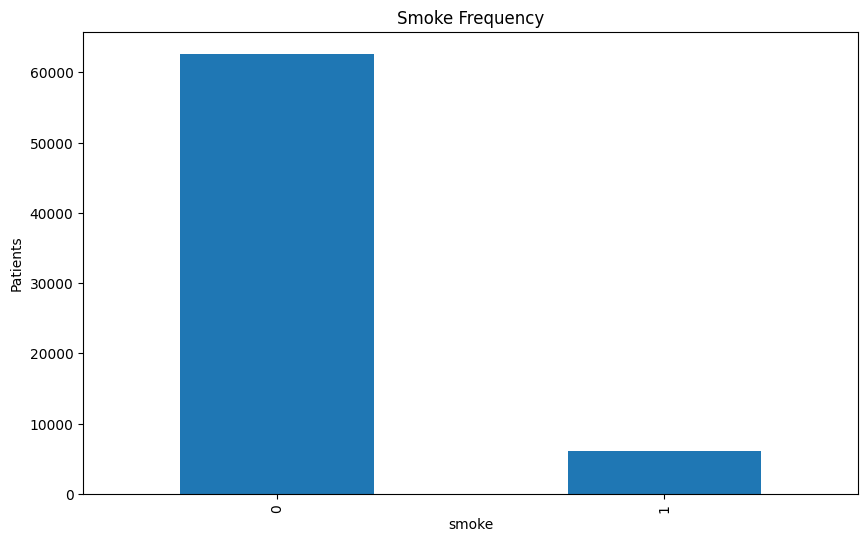


Count for: alcohol_intake
alcohol_intake
0    64990
1     3675
Name: count, dtype: int64


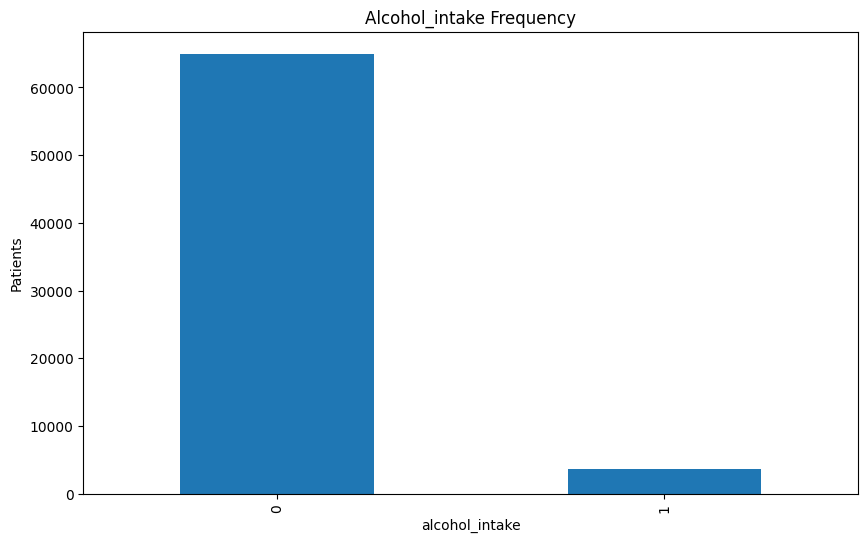


Count for: physical_activity
physical_activity
1    55164
0    13501
Name: count, dtype: int64


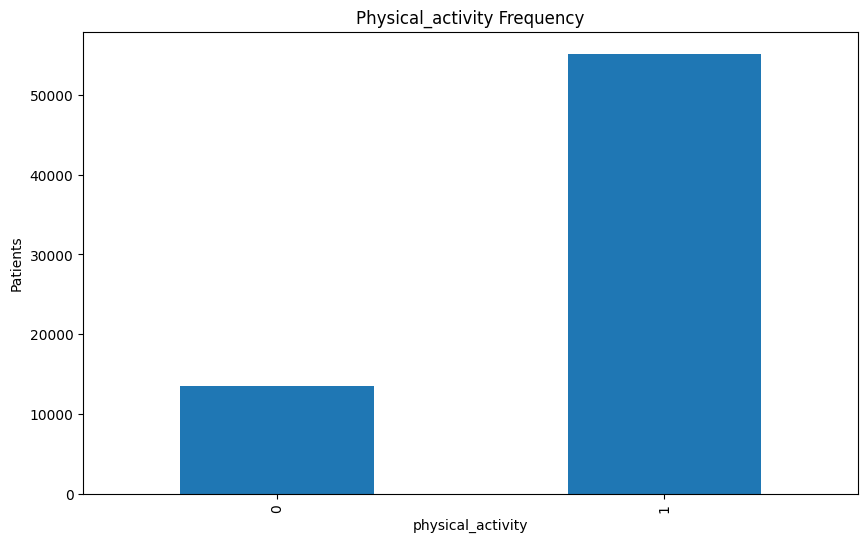

In [42]:
categorical = ['cholesterol', 'gluc', 'smoke', 'alcohol_intake', 'physical_activity']

for cat in categorical:
    print("\nCount for:", cat)
    print(df[cat].value_counts(normalize=False))

    plt.figure(figsize=(10, 6))
    df[cat].value_counts().sort_index().plot(kind='bar')
    plt.title(f'{cat.capitalize()} Frequency')
    plt.xlabel(cat)
    plt.ylabel("Patients")
    plt.show()

### Cardio

cardio
0    34685
1    33980
Name: count, dtype: int64


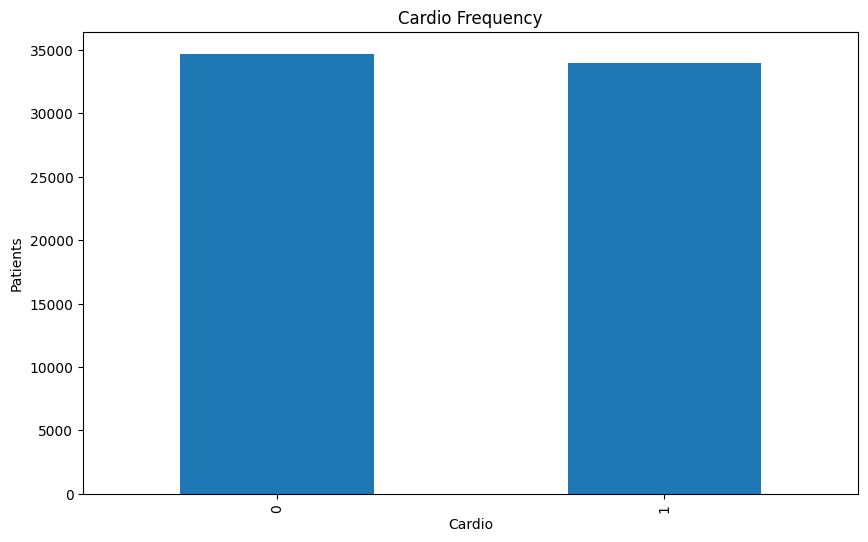

In [44]:
print(df['cardio'].value_counts(normalize=False))

plt.figure(figsize=(10, 6))
df['cardio'].value_counts().plot(kind='bar')
plt.title('Cardio Frequency')
plt.xlabel('Cardio')
plt.ylabel("Patients")
plt.show()

## Eploring Relationships between variables

### Correlation matrix